# Synthesis: Thesis-Ready RQ Conclusion Matrix

## Objective
Integrate RQ1-RQ3 evidence into a single claim ledger with explicit effect sizes, uncertainty context, and decision status.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import (
    HEADLINE_CONTRAST_BY_RQ,
    PRIMARY_COHORT_BY_RQ,
    canon_graph_set,
    optional_csv,
    relative_change,
    require_csv,
)

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

c:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Statistical inference (Methods)

Pre-registered contrasts and **reject / fail to reject** at α = 0.05 (Holm within RQ×cohort) are in `rq_runner/rq_hypothesis_tests.csv`. Interpretation limits (single split, spatial dependence, RQ3 broadcast estimand) are documented in [docs/statistical_inference_rq.md](../docs/statistical_inference_rq.md).

**Evidence map.** `train_eval_3h/station_robustness_statistics.csv` summarizes paired station WMAPE for a **fixed model vs reference** on a **single** graph configuration. `rq_hypothesis_tests.csv` reports **pre-registered contrasts** (different graph sets or station vs broadcast community) with Holm adjustment within each (RQ, cohort) family. Primary reporting cohort is `all` for RQ1–2 and `sparse_espoo` for RQ3 (see `PRIMARY_COHORT_BY_RQ` in `scripts/notebook_reporting.py`).


In [2]:
from IPython.display import Markdown, display

_hypothesis_path = ARTIFACT_ROOT / 'rq_runner' / 'rq_hypothesis_tests.csv'
if not _hypothesis_path.is_file():
    raise FileNotFoundError(
        f'Missing {_hypothesis_path}. Run python -m scripts.experiments.rq_hypothesis_tests --output-dir data/artifacts/experiments/rq_runner after experiment_runners.'
    )
_rqh = pd.read_csv(_hypothesis_path)
_tab = _rqh.sort_values(['rq', 'cohort', 'contrast']).copy()
_tab['is_primary_cohort'] = _tab.apply(
    lambda r: r['cohort'] == PRIMARY_COHORT_BY_RQ.get(str(r['rq']), 'all'),
    axis=1,
)
_cols = [
    'rq',
    'cohort',
    'contrast',
    'mean_delta',
    'ci_lower',
    'ci_upper',
    'p_holm',
    'reject_H0',
    'n_stations_used',
    'is_primary_cohort',
]
if 'H0' in _tab.columns:
    _cols = [
        'rq',
        'cohort',
        'contrast',
        'H0',
        'mean_delta',
        'ci_lower',
        'ci_upper',
        'p_holm',
        'reject_H0',
        'n_stations_used',
        'is_primary_cohort',
    ]
display(Markdown('### All RQ hypothesis tests (summary)'))
display(_tab[_cols])


### All RQ hypothesis tests (summary)

,rq,cohort,contrast,H0,mean_delta,ci_lower,ci_upper,p_holm,reject_H0,n_stations_used,is_primary_cohort
1,RQ1,all,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.039459,-0.052802,-0.024797,0.1860,False,446,True
0,RQ1,all,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.172653,0.149228,0.194020,0.1860,False,446,True
2,RQ1,all,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.061444,0.055829,0.068980,0.1860,False,446,True
33,RQ1,dense,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.032259,-0.046797,-0.019956,0.1779,False,334,False
32,RQ1,dense,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.168972,0.145017,0.200840,0.1779,False,334,False
34,RQ1,dense,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.064941,0.057543,0.072965,0.1779,False,334,False
17,RQ1,espoo,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.053650,-0.056863,-0.045042,1.0000,False,103,False
16,RQ1,espoo,SD_vs_DE,Mean paired station test WMAPE difference (DE ...,0.210553,0.205322,0.212506,0.0003,True,103,False
18,RQ1,espoo,SD_vs_DE+DC,Mean paired station test WMAPE difference (DE+...,0.069519,0.067729,0.070188,1.0000,False,103,False
9,RQ1,helsinki,SD_vs_DC,Mean paired station test WMAPE difference (DC ...,-0.035197,-0.051445,-0.018956,0.1256,False,343,False


In [3]:
results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape')).to_pandas()
results['graph_set'] = results['graph_set'].apply(canon_graph_set)
graph_only = results[results['model'] == 'graph_propagation'].copy()

robustness = optional_csv('train_eval_3h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'paired_sign_permutation_pvalue'))
milestone_best = optional_csv('stgnn_milestones/milestone_best_by_milestone.csv', required_columns=('milestone', 'aggregation', 'test_wmape'))

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'train_eval_3h/station_robustness_statistics.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'station_robustness_statistics.csv').exists()},
    {'artifact': 'stgnn_milestones/milestone_best_by_milestone.csv', 'exists': (ARTIFACT_ROOT / 'stgnn_milestones' / 'milestone_best_by_milestone.csv').exists()},
])

provenance

,artifact,exists
0,rq_runner/results.csv,True
1,train_eval_3h/station_robustness_statistics.csv,True
2,stgnn_milestones/milestone_best_by_milestone.csv,True


In [4]:
def min_wmape(frame: pd.DataFrame, graph_set: str) -> float:
    match = frame[frame['graph_set'] == graph_set]
    return float(match['test_wmape'].min()) if not match.empty else np.nan

rq1 = graph_only[(graph_only['rq'] == 'RQ1') & (graph_only['aggregation'] == 'station')]
rq2 = graph_only[(graph_only['rq'] == 'RQ2') & (graph_only['aggregation'] == 'station')]
rq3 = graph_only[graph_only['rq'] == 'RQ3']

rq1_sd = min_wmape(rq1, 'SD')
rq1_func = np.nanmin([min_wmape(rq1, 'DE'), min_wmape(rq1, 'DC'), min_wmape(rq1, 'DE+DC')])
rq2_all = min_wmape(rq2, 'SD+DE+DC+ATD')
rq2_two = rq2[rq2['graph_set'].str.count(r'\+') == 1]['test_wmape'].min() if not rq2.empty else np.nan
rq3_station = rq3[rq3['aggregation'] == 'station']['test_wmape'].min() if not rq3.empty else np.nan
rq3_community = rq3[rq3['aggregation'] == 'community']['test_wmape'].min() if not rq3.empty else np.nan

conclusion_matrix = pd.DataFrame([
    {'rq': 'RQ1', 'claim': 'Functional graphs outperform SD', 'effect_absolute': rq1_func - rq1_sd if np.isfinite(rq1_func) and np.isfinite(rq1_sd) else np.nan, 'effect_relative': relative_change(rq1_func, rq1_sd) if np.isfinite(rq1_func) and np.isfinite(rq1_sd) else np.nan},
    {'rq': 'RQ2', 'claim': 'All-view fusion improves over best two-view', 'effect_absolute': rq2_all - rq2_two if np.isfinite(rq2_all) and np.isfinite(rq2_two) else np.nan, 'effect_relative': relative_change(rq2_all, rq2_two) if np.isfinite(rq2_all) and np.isfinite(rq2_two) else np.nan},
    {'rq': 'RQ3', 'claim': 'Community aggregation changes sparse-suburban behavior', 'effect_absolute': rq3_community - rq3_station if np.isfinite(rq3_community) and np.isfinite(rq3_station) else np.nan, 'effect_relative': relative_change(rq3_community, rq3_station) if np.isfinite(rq3_community) and np.isfinite(rq3_station) else np.nan},
])

conclusion_matrix

,rq,claim,effect_absolute,effect_relative
0,RQ1,Functional graphs outperform SD,-0.020582,-0.029683
1,RQ2,All-view fusion improves over best two-view,0.067735,0.100637
2,RQ3,Community aggregation changes sparse-suburban ...,-0.448781,-0.605806


In [5]:
uncertainty_rows = []
if robustness is not None:
    robust_df = robustness.to_pandas()
    uncertainty_rows.append({
        'source': 'train_eval robustness',
        'statistic': 'p-value range',
        'value': f"[{robust_df['paired_sign_permutation_pvalue'].min():.4f}, {robust_df['paired_sign_permutation_pvalue'].max():.4f}]"
    })

if milestone_best is not None:
    mdf = milestone_best.to_pandas()
    uncertainty_rows.append({
        'source': 'stgnn milestones',
        'statistic': 'best rows count',
        'value': str(len(mdf)),
    })

uncertainty_ledger = pd.DataFrame(uncertainty_rows)
uncertainty_ledger

,source,statistic,value
0,train_eval robustness,p-value range,"[0.0001, 1.0000]"
1,stgnn milestones,best rows count,6


C:\Users\stefa\AppData\Local\Temp\ipykernel_616\2434894138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=viz_df, x='rq', y='effect_relative', palette='crest')


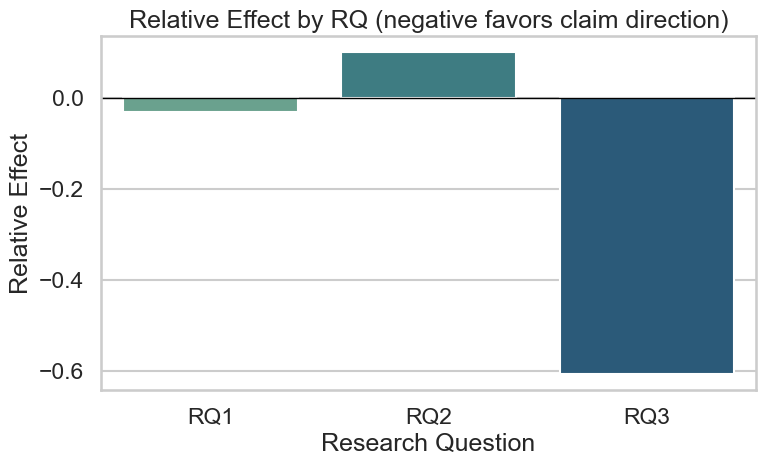

In [6]:
viz_df = conclusion_matrix.dropna(subset=['effect_relative']).copy()

if viz_df.empty:
    print('No finite effect_relative values available for synthesis plot.')
else:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=viz_df, x='rq', y='effect_relative', palette='crest')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_title('Relative Effect by RQ (negative favors claim direction)')
    ax.set_ylabel('Relative Effect')
    ax.set_xlabel('Research Question')
    plt.tight_layout()
    plt.show()

## Threats To Validity

- External validity is bounded by Helsinki-Espoo context and current temporal split regime.
- Synthesis consistency depends on artifact freshness; stale outputs can cause claim drift.
- Cross-RQ comparability assumes aligned metric definitions and equivalent preprocessing settings.

In [7]:
def claim_status_point(effect: float) -> str:
    if not np.isfinite(effect):
        return 'insufficient_data'
    return 'supported' if effect < 0 else 'mixed_or_not_supported'


def formal_primary_status(rq: str, sub_primary: pd.DataFrame) -> tuple[str, str]:
    if sub_primary.empty:
        return 'no_hypothesis_rows', ''
    if rq in ('RQ1', 'RQ2'):
        ok = (sub_primary['reject_H0']) & (sub_primary['mean_delta'] < 0)
        if ok.any():
            return 'reject_H0_negative_delta', (
                f'At least one contrast in primary cohort {PRIMARY_COHORT_BY_RQ[rq]} rejects H0 with negative mean_delta'
            )
        if (~sub_primary['reject_H0']).all():
            return 'fail_to_reject_all_contrasts', 'No Holm rejections in primary cohort'
        return 'reject_without_consistent_direction', 'Rejections exist but not with negative mean_delta throughout'
    if rq == 'RQ3':
        if sub_primary['reject_H0'].any():
            return 'reject_H0_any_contrast', 'At least one station vs broadcast contrast rejects in primary cohort'
        return 'fail_to_reject_all_contrasts', 'No Holm rejections in primary cohort'
    return 'unknown_rq', ''


def combined_claim_status(row: pd.Series) -> str:
    pt = row['claim_status_point']
    rq = row['rq']
    formal = row['formal_primary_label']
    if pt == 'insufficient_data':
        return 'insufficient_data'
    if formal == 'no_hypothesis_rows':
        return 'point_only_missing_inferential_rows'
    dir_formal_ok = formal in ('reject_H0_negative_delta', 'reject_H0_any_contrast')
    point_sup = pt == 'supported'
    if point_sup and dir_formal_ok:
        return 'supported_point_and_primary_inferential'
    if point_sup and not dir_formal_ok:
        return 'supported_point_inferential_weak_or_inconsistent'
    if (not point_sup) and dir_formal_ok:
        return 'inferential_signal_without_point_claim_support'
    return 'not_supported_on_both'


decision_table = conclusion_matrix.copy()
decision_table['claim_status_point'] = decision_table['effect_absolute'].apply(claim_status_point)


def merge_formal(row: pd.Series) -> pd.Series:
    rq = row['rq']
    prim = PRIMARY_COHORT_BY_RQ.get(rq, 'all')
    sub = _rqh[(_rqh['rq'] == rq) & (_rqh['cohort'] == prim)]
    label, detail = formal_primary_status(rq, sub)
    headline = HEADLINE_CONTRAST_BY_RQ.get(rq, '')
    hrows = sub[sub['contrast'] == headline]
    return pd.Series(
        {
            'primary_cohort': prim,
            'headline_contrast': headline,
            'formal_primary_label': label,
            'formal_primary_detail': detail,
            'headline_reject_H0': bool(hrows['reject_H0'].iloc[0]) if len(hrows) == 1 else False,
            'headline_mean_delta': float(hrows['mean_delta'].iloc[0]) if len(hrows) == 1 else np.nan,
            'headline_ci_lower': float(hrows['ci_lower'].iloc[0]) if len(hrows) == 1 else np.nan,
            'headline_ci_upper': float(hrows['ci_upper'].iloc[0]) if len(hrows) == 1 else np.nan,
        }
    )


decision_table = pd.concat([decision_table, decision_table.apply(merge_formal, axis=1)], axis=1)
decision_table['claim_status'] = decision_table.apply(combined_claim_status, axis=1)
decision_table['rationale'] = decision_table.apply(
    lambda r: (
        f"point effect_absolute={r['effect_absolute']:.6f}; primary cohort={r['primary_cohort']}; "
        f"formal={r['formal_primary_label']}; headline {r['headline_contrast']} reject={r['headline_reject_H0']}"
        if np.isfinite(r['effect_absolute'])
        else 'missing effect estimate'
    ),
    axis=1,
)

publication_ready = bool(
    (decision_table['claim_status'] != 'insufficient_data').all()
    and (decision_table['claim_status'] != 'point_only_missing_inferential_rows').all()
)

decision_table, pd.DataFrame([{'publication_ready': publication_ready, 'n_claims': len(decision_table)}])

(    rq                                              claim  effect_absolute  \
 0  RQ1                    Functional graphs outperform SD        -0.020582   
 1  RQ2        All-view fusion improves over best two-view         0.067735   
 2  RQ3  Community aggregation changes sparse-suburban ...        -0.448781   
 
    effect_relative      claim_status_point primary_cohort  \
 0        -0.029683               supported            all   
 1         0.100637  mixed_or_not_supported            all   
 2        -0.605806               supported   sparse_espoo   
 
             headline_contrast          formal_primary_label  \
 0                    SD_vs_DC  fail_to_reject_all_contrasts   
 1           all_view_vs_DE_DC  fail_to_reject_all_contrasts   
 2  station_vs_community_DE_DC        reject_H0_any_contrast   
 
                                formal_primary_detail  headline_reject_H0  \
 0               No Holm rejections in primary cohort               False   
 1               No 